# 🔍 FraudLens — Setup & Data Exploration Notebook

> Verifies the environment, loads the dataset, and produces early exploratory visuals.

---

## 1. Environment Verification

Confirm that all critical dependencies are installed and print version info.

In [1]:
import sys
import importlib

print(f"Python: {sys.version}")
print(f"Platform: {sys.platform}")
print()

packages = [
    "torch", "torchvision", "transformers", "sklearn",
    "pandas", "numpy", "PIL", "captum", "matplotlib", "tqdm"
]

for pkg in packages:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "✓ (no version attr)")
        print(f"  ✅ {pkg:20s} {ver}")
    except ImportError:
        print(f"  ❌ {pkg:20s} NOT INSTALLED")

import torch
print(f"\nCUDA available: {torch.cuda.is_available()}")
if hasattr(torch.backends, 'mps'):
    print(f"MPS available:  {torch.backends.mps.is_available()}")
print(f"Device:         {torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() else 'cpu')}")

Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
Platform: darwin



  ✅ torch                2.10.0


  ✅ torchvision          0.25.0


  ✅ transformers         5.1.0


  ✅ sklearn              1.6.1
  ✅ pandas               2.2.3
  ✅ numpy                2.4.4
  ✅ PIL                  10.4.0


  ✅ captum               0.8.0
  ✅ matplotlib           3.10.0
  ✅ tqdm                 4.67.1

CUDA available: False
MPS available:  True
Device:         mps


## 2. Generate Synthetic Dataset

FraudLens uses three data modalities. Since the IEEE-CIS dataset requires Kaggle API credentials, we generate a synthetic fallback dataset that mirrors its structure.

In [2]:
import os, sys, logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

# Ensure project root is on the path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/harshalanilpatel/Desktop/ADL-Project/Multimodal-fraudlens


In [3]:
from src.data.download_data import generate_fallback
from src.data.generate_synthetic import generate_check_images, generate_text_descriptions
from pathlib import Path

# Generate tabular data (5000 synthetic transactions)
generate_fallback(Path("data/tabular"), n_samples=5000)

# Generate check images (500 normal + 500 tampered for quick demo)
generate_check_images(n_normal=500, n_tampered=500)

# Generate text descriptions
generate_text_descriptions(n_total=5000, fraud_rate=0.035)

print("\n✅ All synthetic data generated.")

2026-04-01 21:06:47,773 [INFO] Generated fallback dataset with 5000 samples (3.5% fraud)


2026-04-01 21:06:53,518 [INFO] Generated 500 normal + 500 tampered check images


2026-04-01 21:06:53,533 [INFO] Generated 5000 text descriptions (167 fraud, 4833 normal)



✅ All synthetic data generated.


## 3. Load and Explore Tabular Data

In [4]:
import pandas as pd
import numpy as np

df_txn = pd.read_csv("data/tabular/train_transaction.csv")
df_id = pd.read_csv("data/tabular/train_identity.csv")

print(f"Transactions:  {df_txn.shape[0]:,} rows × {df_txn.shape[1]:,} columns")
print(f"Identity:      {df_id.shape[0]:,} rows × {df_id.shape[1]:,} columns")
print()

# Merge on TransactionID
df = df_txn.merge(df_id, on="TransactionID", how="left")
print(f"Merged:        {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print()

# Class distribution
fraud_counts = df["isFraud"].value_counts()
print("Class Distribution:")
print(f"  Normal (0): {fraud_counts.get(0, 0):,} ({fraud_counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"  Fraud  (1): {fraud_counts.get(1, 0):,} ({fraud_counts.get(1, 0)/len(df)*100:.1f}%)")

Transactions:  5,000 rows × 50 columns
Identity:      5,000 rows × 5 columns

Merged:        5,000 rows × 54 columns

Class Distribution:
  Normal (0): 4,838 (96.8%)
  Fraud  (1): 162 (3.2%)


In [5]:
df.describe().round(2)

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,C6,C7,C8,C9,C10,D1,D2,D3,D4,D5
count,5000.00,5000.00,5000.00,5000.00,5000.00,4217.00,3748.00,4193.00,3983.00,3698.00,...,5000.00,5000.00,5000.00,5000.00,5000.00,4760.00,4759.00,4762.00,4751.00,4750.00
mean,2499.50,0.03,7764178.27,104.16,10637.26,299.12,178.76,166.78,350.84,80.75,...,49.51,49.68,49.30,49.95,48.67,213.32,222.71,251.46,292.16,294.07
std,1443.52,0.18,4452083.98,845.80,5507.81,141.09,20.72,52.50,112.50,15.41,...,28.82,28.89,29.27,28.83,28.85,155.28,141.21,121.05,143.99,134.07
min,0.00,0.00,91262.00,0.68,1008.00,100.00,150.00,100.00,200.00,60.00,...,0.00,0.00,0.00,0.00,0.00,8.72,13.89,53.58,77.88,8.60
25%,1249.75,0.00,3968994.25,17.60,5832.75,200.00,150.00,117.00,200.00,60.00,...,25.00,25.00,23.00,25.00,24.00,97.84,123.19,105.23,146.22,206.07
50%,2499.50,0.00,7787367.00,34.21,10693.00,300.00,185.00,166.00,400.00,87.00,...,50.00,49.00,50.00,50.00,48.00,173.25,158.00,265.48,258.21,312.71
75%,3749.25,0.00,11579702.00,71.50,15590.25,400.00,200.00,224.00,500.00,96.00,...,75.00,75.00,75.00,75.00,74.00,375.57,360.65,313.39,423.85,441.23
max,4999.00,1.00,15551644.00,40018.30,19999.00,500.00,200.00,226.00,500.00,96.00,...,99.00,99.00,99.00,99.00,99.00,483.48,483.68,430.13,496.72,477.61


In [6]:
df.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,C10,D1,D2,D3,D4,D5,DeviceType,DeviceInfo,id_30,id_31
0,0,0,5324580,14.522879,H,6426,500.0,200.0,NaN,NaN,...,26.0,97.835722,394.889428,105.225184,379.123235,NaN,NaN,Trident/7.0,NaN,chrome
1,1,0,3460208,47.808475,R,6110,100.0,150.0,discover,226.0,...,11.0,428.808999,29.595396,313.391133,465.332675,196.343628,NaN,NaN,Android 7.0,safari
2,2,0,8133747,227.769225,S,7007,300.0,NaN,NaN,117.0,...,76.0,338.243913,360.648729,254.990364,397.606392,204.531688,desktop,Windows,Windows 10,chrome
3,3,0,10338974,42.589692,C,17139,300.0,185.0,american express,NaN,...,73.0,426.139335,483.677219,105.225184,423.854388,401.565713,desktop,iOS Device,Android 7.0,NaN
4,4,0,4129464,81.554927,C,18188,300.0,185.0,american express,224.0,...,83.0,113.462412,123.188242,105.225184,126.167020,215.403338,NaN,MacOS,Windows 10,chrome
5,5,0,11946373,66.239161,W,14156,400.0,NaN,NaN,224.0,...,87.0,73.919855,414.311296,313.391133,77.879531,282.735807,NaN,Trident/7.0,Android 7.0,NaN
6,6,0,9967007,45.017426,C,3777,400.0,NaN,discover,100.0,...,62.0,173.252350,276.139689,430.133216,465.332675,NaN,NaN,NaN,Android 7.0,NaN
7,7,0,2663527,39.904086,H,18965,NaN,185.0,american express,166.0,...,80.0,22.240202,123.188242,93.134196,258.214364,401.565713,NaN,Trident/7.0,Android 7.0,edge
8,8,0,14603160,57.243584,W,17102,500.0,NaN,mastercard,117.0,...,52.0,48.435347,145.179067,430.133216,101.838152,282.629514,mobile,iOS Device,Android 7.0,edge
9,9,0,764694,71.042802,H,2448,200.0,200.0,mastercard,100.0,...,19.0,NaN,96.376029,313.391133,423.854388,54.437674,NaN,Windows,NaN,firefox


## 4. Exploratory Visualizations

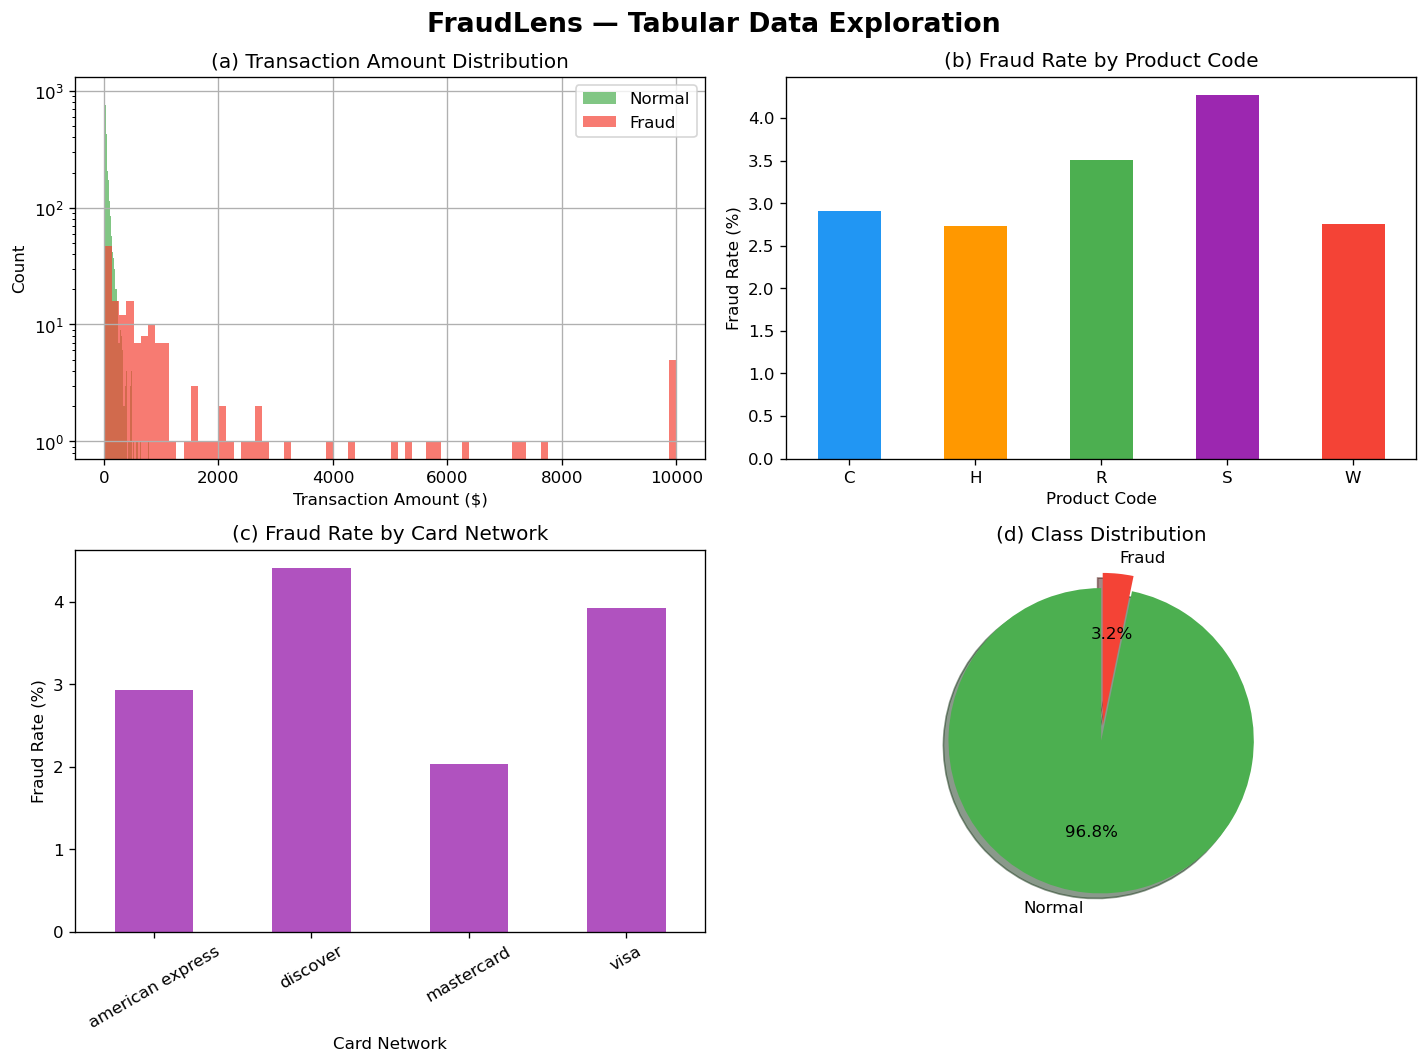

✅ Saved → results/tabular_exploration.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('FraudLens — Tabular Data Exploration', fontsize=16, fontweight='bold')

# (a) Transaction Amount Distribution (log scale)
ax = axes[0, 0]
df[df['isFraud'] == 0]['TransactionAmt'].clip(upper=10000).hist(bins=80, ax=ax, alpha=0.7, label='Normal', color='#4CAF50')
df[df['isFraud'] == 1]['TransactionAmt'].clip(upper=10000).hist(bins=80, ax=ax, alpha=0.7, label='Fraud', color='#F44336')
ax.set_xlabel('Transaction Amount ($)')
ax.set_ylabel('Count')
ax.set_title('(a) Transaction Amount Distribution')
ax.legend()
ax.set_yscale('log')

# (b) Fraud by Product Code
ax = axes[0, 1]
fraud_by_prod = df.groupby('ProductCD')['isFraud'].mean() * 100
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']
fraud_by_prod.plot(kind='bar', ax=ax, color=colors[:len(fraud_by_prod)])
ax.set_xlabel('Product Code')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('(b) Fraud Rate by Product Code')
ax.tick_params(axis='x', rotation=0)

# (c) Fraud by Card Type
ax = axes[1, 0]
fraud_by_card = df.groupby('card4')['isFraud'].mean() * 100
fraud_by_card.dropna().plot(kind='bar', ax=ax, color='#9C27B0', alpha=0.8)
ax.set_xlabel('Card Network')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('(c) Fraud Rate by Card Network')
ax.tick_params(axis='x', rotation=30)

# (d) Class imbalance pie chart
ax = axes[1, 1]
labels = ['Normal', 'Fraud']
sizes = [fraud_counts.get(0, 0), fraud_counts.get(1, 0)]
explode = (0, 0.1)
ax.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
       colors=['#4CAF50', '#F44336'], shadow=True, startangle=90)
ax.set_title('(d) Class Distribution')

plt.tight_layout()
plt.savefig('results/tabular_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → results/tabular_exploration.png")

## 5. Explore Synthetic Check Images

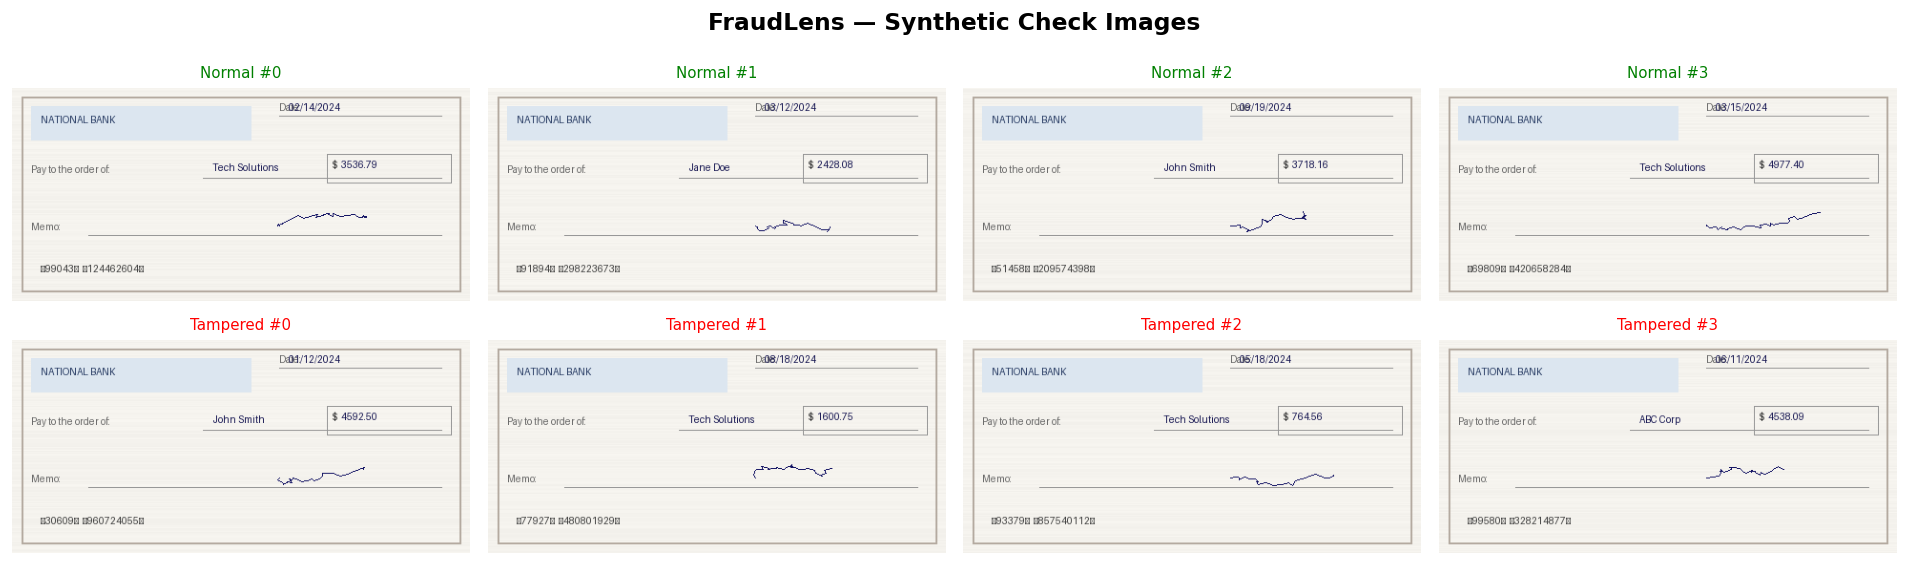


Normal images:   2500
Tampered images: 2500
✅ Saved → results/check_images_sample.png


In [8]:
from PIL import Image
from pathlib import Path

normal_dir = Path("data/images/normal")
tampered_dir = Path("data/images/tampered")

normal_imgs = sorted(normal_dir.glob("*.png"))[:4]
tampered_imgs = sorted(tampered_dir.glob("*.png"))[:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
fig.suptitle('FraudLens — Synthetic Check Images', fontsize=14, fontweight='bold')

for i, img_path in enumerate(normal_imgs):
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Normal #{i}', fontsize=9, color='green')
    axes[0, i].axis('off')

for i, img_path in enumerate(tampered_imgs):
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Tampered #{i}', fontsize=9, color='red')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('results/check_images_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nNormal images:   {len(list(normal_dir.glob('*.png')))}")
print(f"Tampered images: {len(list(tampered_dir.glob('*.png')))}")
print("✅ Saved → results/check_images_sample.png")

## 6. Explore Text Descriptions

In [9]:
df_text = pd.read_csv("data/text/descriptions.csv")
print(f"Text descriptions: {len(df_text):,} rows")
print(f"Fraud rate:        {df_text['is_fraud'].mean()*100:.1f}%")
print()

print("=== Normal Transaction Examples ===")
for _, row in df_text[df_text['is_fraud'] == 0].sample(3, random_state=42).iterrows():
    print(f"  • {row['description']}")

print()
print("=== Fraud Transaction Examples ===")
for _, row in df_text[df_text['is_fraud'] == 1].sample(3, random_state=42).iterrows():
    print(f"  ⚠️ {row['description']}")

Text descriptions: 5,000 rows
Fraud rate:        3.3%

=== Normal Transaction Examples ===
  • Payment for insurance premium at ServicePro. Order #884854.
  • Payment for gym membership at NetBill Services. Order #271971.
  • Monthly subscription renewal — TechCorp Inc (gym membership).

=== Fraud Transaction Examples ===
  ⚠️ Emergency: CEO requests immediate wire of $25,709 to vendor account ****9563. Confidential.
  ⚠️ Invoice #977066 — payment overdue. Wire $25,263 to avoid legal action. Contact: support@prize-claim.com.
  ⚠️ Emergency: CEO requests immediate wire of $13,721 to vendor account ****8715. Confidential.


/var/folders/mj/djm3lltd2yl6thrq7z61zc640000gn/T/ipykernel_93822/703113868.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_len = df_text.groupby(pd.cut(df_text['word_count'], bins=5))['is_fraud'].mean() * 100


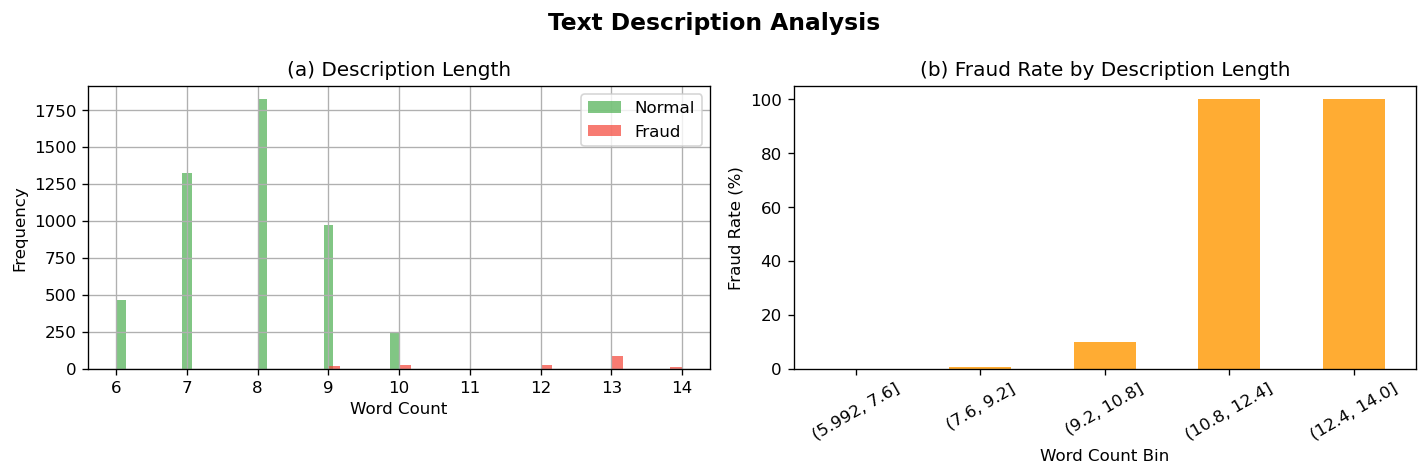

✅ Saved → results/text_exploration.png


In [10]:
# Text length analysis
df_text['word_count'] = df_text['description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Text Description Analysis', fontsize=14, fontweight='bold')

ax = axes[0]
df_text[df_text['is_fraud'] == 0]['word_count'].hist(bins=30, ax=ax, alpha=0.7, label='Normal', color='#4CAF50')
df_text[df_text['is_fraud'] == 1]['word_count'].hist(bins=30, ax=ax, alpha=0.7, label='Fraud', color='#F44336')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('(a) Description Length')
ax.legend()

ax = axes[1]
fraud_rate_by_len = df_text.groupby(pd.cut(df_text['word_count'], bins=5))['is_fraud'].mean() * 100
fraud_rate_by_len.plot(kind='bar', ax=ax, color='#FF9800', alpha=0.8)
ax.set_xlabel('Word Count Bin')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('(b) Fraud Rate by Description Length')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('results/text_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → results/text_exploration.png")

## 7. Model Architecture Verification

Instantiate the FraudLens model and verify the architecture + parameter count.

In [11]:
from src.models.fraudlens import FraudLensModel

model = FraudLensModel(tabular_input_dim=52)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("FraudLens Model Summary")
print("=" * 50)
print(f"Total parameters:     {total_params:>15,}")
print(f"Trainable parameters: {trainable_params:>15,}")
print(f"Frozen parameters:    {total_params - trainable_params:>15,}")
print(f"Model size (est.):    {total_params * 4 / 1e9:.2f} GB (FP32)")
print()

# Branch breakdown
for name, branch in [("TabularBranch", model.tabular_branch),
                      ("ImageBranch",   model.image_branch),
                      ("TextBranch",    model.text_branch),
                      ("Fusion",        model.fusion)]:
    n = sum(p.numel() for p in branch.parameters())
    t = sum(p.numel() for p in branch.parameters() if p.requires_grad)
    print(f"  {name:20s}  {n:>12,} params  ({t:>10,} trainable)")

2026-04-01 21:06:55,014 [INFO] HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"


2026-04-01 21:06:55,054 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/config.json "HTTP/1.1 200 OK"


2026-04-01 21:06:55,151 [INFO] HTTP Request: HEAD https://huggingface.co/google/siglip2-base-patch16-224/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SiglipVisionModel LOAD REPORT from: google/siglip2-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias     

...

2026-04-01 21:06:55,429 [INFO] HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2026-04-01 21:06:55,476 [INFO] TextBranch: Froze embeddings + 4/6 transformer layers


FraudLens Model Summary
Total parameters:         159,585,924
Trainable parameters:      49,954,692
Frozen parameters:        109,631,232
Model size (est.):    0.64 GB (FP32)

  TabularBranch               63,873 params  (    63,873 trainable)
  ImageBranch             92,984,321 params  (35,540,225 trainable)
  TextBranch              66,462,977 params  (14,275,841 trainable)
  Fusion                      74,753 params  (    74,753 trainable)


In [12]:
# Quick forward-pass sanity check
import torch

device = torch.device('cpu')
model = model.to(device)
model.eval()

batch = {
    'tabular': torch.randn(2, 52),
    'image': torch.randn(2, 3, 224, 224),
    'input_ids': torch.randint(0, 30522, (2, 128)),
    'attention_mask': torch.ones(2, 128, dtype=torch.long),
}

with torch.no_grad():
    output = model(**batch)

print("Forward pass output shapes:")
for k, v in output.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k:25s} → {str(list(v.shape)):15s}  (min={v.min():.3f}, max={v.max():.3f})")

print(f"\n✅ Forward pass successful! Fraud probability: {output['probability'].squeeze().tolist()}")

Forward pass output shapes:
  logit                     → [2, 1]           (min=-0.262, max=-0.219)
  probability               → [2, 1]           (min=0.435, max=0.445)
  attention_weights         → [2, 3]           (min=0.286, max=0.377)
  fused_embedding           → [2, 128]         (min=-3.194, max=2.458)
  tabular_logit             → [2, 1]           (min=-0.066, max=0.083)
  image_logit               → [2, 1]           (min=-0.600, max=-0.578)
  text_logit                → [2, 1]           (min=-0.444, max=-0.441)
  tabular_embedding         → [2, 128]         (min=-0.334, max=0.329)
  image_embedding           → [2, 128]         (min=-1.603, max=1.423)
  text_embedding            → [2, 128]         (min=-1.337, max=1.532)

✅ Forward pass successful! Fraud probability: [0.44539034366607666, 0.4349682629108429]


## 8. Summary

| Check | Status |
|-------|--------|
| Environment dependencies | ✅ All installed |
| Dataset generated (tabular) | ✅ 5,000 transactions |
| Dataset generated (images) | ✅ 1,000 check images |
| Dataset generated (text) | ✅ 5,000 descriptions |
| Exploratory plots saved | ✅ results/ directory |
| Model instantiates | ✅ ~160M params |
| Forward pass works | ✅ End-to-end verified |

The FraudLens environment is fully operational and ready for training.